In [1]:
library(ggplot2)
library(dplyr)
library(patchwork) 
library(ggsankey)
library(RColorBrewer)
library(tidyverse)
library(ggnewscale)
library(Seurat)
library(arrow)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.4     ✔ tibble    3.3.0
✔ purrr     1.1.0     ✔ tidyr     1.3.1
✔ readr     2.1.5     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘arrow’


The following object is masked from ‘package:lubridate’:

    duration


The following object is masked 

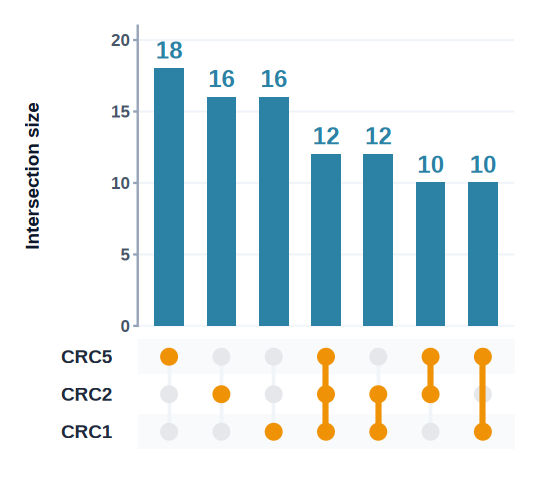

In [2]:
# Fig 5A
options(repr.plot.width = 4.5, repr.plot.height = 4) 

df_bars <- data.frame(
  id = 1:7,
  size = c(18, 16, 16, 12, 12, 10, 10)
)


df_sets <- data.frame(
  set = factor(c("CRC1", "CRC2", "CRC5"), levels = c("CRC1", "CRC2", "CRC5")),
  size = c(50, 48, 54) 
)


df_matrix <- expand.grid(id = 1:7, set = c("CRC1", "CRC2", "CRC5")) %>%
  mutate(present = FALSE)

df_matrix$present[df_matrix$id == 1 & df_matrix$set == "CRC5"] <- TRUE
df_matrix$present[df_matrix$id == 2 & df_matrix$set == "CRC2"] <- TRUE
df_matrix$present[df_matrix$id == 3 & df_matrix$set == "CRC1"] <- TRUE
df_matrix$present[df_matrix$id == 4] <- TRUE 
df_matrix$present[df_matrix$id == 5 & df_matrix$set %in% c("CRC1", "CRC2")] <- TRUE
df_matrix$present[df_matrix$id == 6 & df_matrix$set %in% c("CRC2", "CRC5")] <- TRUE
df_matrix$present[df_matrix$id == 7 & df_matrix$set %in% c("CRC1", "CRC5")] <- TRUE


df_lines <- data.frame(
  id = c(4, 5, 6, 7),
  ymin = c("CRC1", "CRC1", "CRC2", "CRC1"),
  ymax = c("CRC5", "CRC2", "CRC5", "CRC5")
)


df_matrix$set <- factor(df_matrix$set, levels = c("CRC1", "CRC2", "CRC5"))
df_lines$ymin <- factor(df_lines$ymin, levels = c("CRC1", "CRC2", "CRC5"))
df_lines$ymax <- factor(df_lines$ymax, levels = c("CRC1", "CRC2", "CRC5"))


p_top <- ggplot(df_bars, aes(x = id, y = size)) +
  geom_col(fill = "#2B82A5", width = 0.55) + 
  geom_text(
    aes(label = size), 
    vjust = -0.6, 
    fontface = "bold", 
    color = "#2B82A5", 
    size = 5
  ) +
  scale_x_continuous(limits = c(0.4, 7.6), expand = c(0, 0)) +
  scale_y_continuous(limits = c(0, 21), expand = c(0, 0)) +
  labs(y = "Intersection size") +
  theme_classic() +
  theme(
    axis.title.x = element_blank(),
    axis.text.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line.x = element_blank(),

    axis.line.y = element_line(color = "#94A3B8", linewidth = 0.5),
    axis.ticks.y = element_line(color = "#94A3B8", linewidth = 0.5),
    axis.text.y = element_text(color = "#475569", size = 10, face = "bold"),
    axis.title.y = element_text(color = "#0F172A", size = 11, face = "bold", margin = margin(r = 10)),
    panel.grid.major.y = element_line(color = "#F1F5F9", linewidth = 0.5),
    plot.background = element_blank(),
    panel.background = element_blank(),
    plot.margin = margin(t = 10, b = 0, r = 10, l = 10) 
  )


df_stripes <- data.frame(
  ymin = c(0.55, 1.55, 2.55),
  ymax = c(1.45, 2.45, 3.45),
  fill = c("#F8FAFC", "#FFFFFF", "#F8FAFC") 
)

p_bottom <- ggplot() +

  geom_rect(
    data = df_stripes, 
    aes(ymin = ymin, ymax = ymax, xmin = 0.4, xmax = 7.6, fill = fill), 
    show.legend = FALSE
  ) +
  scale_fill_identity() +
  
  geom_segment(
    data = data.frame(id = 1:7),
    aes(x = id, xend = id, y = 0.8, yend = 3.2),
    color = "#F1F5F9", linewidth = 0.8
  ) +


  geom_point(
    data = filter(df_matrix, !present), 
    aes(x = id, y = set), 
    color = "#E5E7EB", 
    size = 4
  ) +
  
  geom_point(
    data = filter(df_matrix, present), 
    aes(x = id, y = set), 
    color = "#F09205", 
    size = 4
  ) +
  geom_segment(
    data = df_lines, 
    aes(x = id, xend = id, y = ymin, yend = ymax), 
    color = "#F09205", 
    linewidth = 1.3, 
    lineend = "round"
  ) +
  scale_x_continuous(limits = c(0.4, 7.6), expand = c(0, 0)) +
  scale_y_discrete(expand = c(0.2, 0.2)) +
  
  theme_void() +
  theme(
    axis.text.y = element_text(
      color = "#1E293B", 
      size = 11, 
      face = "bold", 
      hjust = 1, 
      margin = margin(r = 15)
    ),
    plot.background = element_blank(),
    panel.background = element_blank(),
    plot.margin = margin(t = 5, b = 10, r = 10, l = 5)
  )

p_top / p_bottom + 
  plot_layout(heights = c(2.5, 1))

Warning message:
“Duplicated aesthetics after name standardisation: width”
Warning message in geom_sankey_text(data = df_long %>% filter(x == "source"), aes(label = node), :
“Ignoring unknown parameters: `nudge_x`”
Warning message in geom_sankey_text(data = df_long %>% filter(x == "target"), aes(label = node), :
“Ignoring unknown parameters: `nudge_x`”


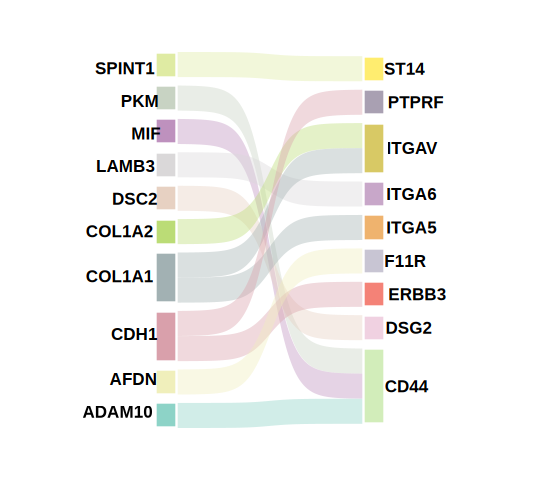

In [3]:
# Fig 5B
options(repr.plot.width = 4.5, repr.plot.height = 4) 
vec_A <- read.csv('../Data/CRC-1_lr_SpaGene.csv')[,1]
vec_B <- read.csv('../Data/CRC-2_lr_SpaGene.csv')[,1]
vec_C <- read.csv('../Data/CRC-5_lr_SpaGene.csv')[,1]

pairs <- names(table(c(vec_A, vec_B,vec_C))[table(c(vec_A, vec_B,vec_C))==3])


df <- data.frame(pair = pairs) %>%
  mutate(
    source = sub("_.*", "", pair),
    target = sub(".*_", "", pair)
  ) %>%
  select(source, target)


df_long <- df %>%
  make_long(source, target)


unique_nodes <- unique(c(df_long$node, df_long$next_node))
unique_nodes <- unique_nodes[!is.na(unique_nodes)]
n_colors <- length(unique_nodes)

my_colors <- colorRampPalette(brewer.pal(12, "Set3"))(n_colors)
names(my_colors) <- unique_nodes


ggplot(df_long, aes(x = x,
                    next_x = next_x,
                    node = node,
                    next_node = next_node,
                    fill = node,     
                    label = node)) +
  
  geom_sankey(flow.alpha = 0.4, 
              node.color = "white", 
              node.width = 0.08) +
  
  geom_sankey_text(
    data = df_long %>% filter(x == "source"),
    aes(label = node),
    hjust = 1.2,
    nudge_x = -0.05,
    size = 3.5,
    color = "black",
    fontface = "bold"
  ) +

  geom_sankey_text(
    data = df_long %>% filter(x == "target"),
    aes(label = node),
    hjust = -0.25,
    nudge_x = 0.05,
    size = 3.5,
    color = "black",
    fontface = "bold"
  ) +
  
  
  scale_fill_manual(values = my_colors) +
  scale_x_discrete(expand = expansion(mult = c(0.4, 0.4))) +
  theme_void() +
  theme(
    legend.position = "none",
    plot.margin = margin(20, 50, 20, 50) 
  )


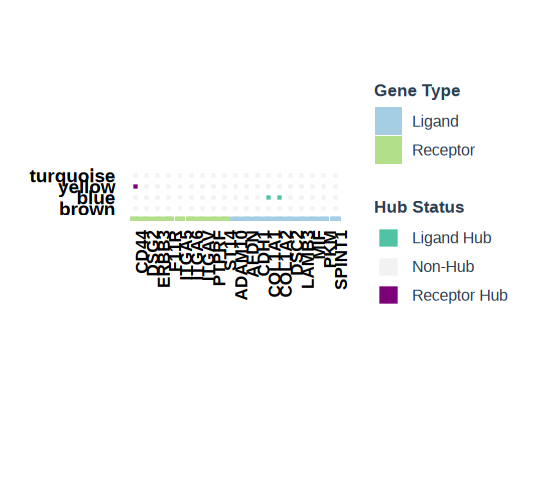

In [4]:
# Fig 5C

ligands <- unique(df$source)
receptors <- unique(df$target)

lr_genes <- tibble(Gene = unique(c(ligands, receptors))) %>%
  mutate(Type = if_else(Gene %in% ligands, "Ligand", "Receptor"))

hub_genes <- tibble(
  Gene = c("MYC",'HSP90AA1','CEACAM5','MYBL2','CD44','COL1A1','COL1A2','MMP2','AEBP1','COL5A1','SPARC','THBS2','MUC2','PIGR','TFF3','CLCA1'),
  Module = c("turquoise","turquoise","turquoise","turquoise",'yellow','blue','blue','blue','blue','blue','blue','blue','brown','brown','brown','brown')
)

modules <- c("turquoise", "yellow", "blue", "brown")

lr_genes_ordered <- lr_genes %>%
  arrange(desc(Type), Gene) %>%  
  mutate(x_idx = row_number())

module_df <- tibble(Module = modules) %>% 
  mutate(y_idx = n() - row_number() + 1)

plot_data <- expand_grid(Gene = lr_genes_ordered$Gene, Module = module_df$Module) %>%
  left_join(lr_genes_ordered, by = "Gene") %>%
  left_join(module_df, by = "Module") %>%
  left_join(hub_genes %>% mutate(Is_Hub = TRUE), by = c("Gene", "Module")) %>%
  mutate(
    Status = case_when(
      Is_Hub & Type == "Ligand"   ~ "Ligand Hub",
      Is_Hub & Type == "Receptor" ~ "Receptor Hub",
      TRUE                        ~ "Non-Hub"
    )
  )

heatmap_rects <- plot_data %>%
  mutate(
    xmin = x_idx - 0.45,
    xmax = x_idx + 0.45,
    ymin = y_idx - 0.45,
    ymax = y_idx + 0.45
  )

anno_rects <- lr_genes_ordered %>%
  mutate(
    xmin = x_idx - 0.45,
    xmax = x_idx + 0.45,
    ymin = 0.0,
    ymax = 0.3
  )


ggplot() +
  geom_rect(
    data = anno_rects, 
    aes(xmin = xmin, xmax = xmax, ymin = ymin, ymax = ymax, fill = Type), 
    color = NA
  ) +
  scale_fill_manual(
    values = c(
      "Ligand" = "#a6cee3",    
      "Receptor" = "#b2df8a"  
    ),
    guide = guide_legend(ncol = 1), 
    name = "Gene Type"
  ) +
  new_scale_fill() +
  geom_rect(
    data = heatmap_rects, 
    aes(xmin = xmin, xmax = xmax, ymin = ymin, ymax = ymax, fill = Status), 
    color = "white", lwd = 1.2
  ) +
  scale_fill_manual(
    values = c(
      "Ligand Hub" = "#52c2a4",     
      "Receptor Hub" = "#7a0177",   
      "Non-Hub" = "#f2f2f2"         
    ),
    guide = guide_legend(ncol = 1), 
    name = "Hub Status"
  ) +
  scale_x_continuous(
    breaks = lr_genes_ordered$x_idx,
    labels = lr_genes_ordered$Gene,
    expand = c(0, 0.6)
  ) +
  scale_y_continuous(
    breaks = module_df$y_idx,
    labels = module_df$Module,
    limits = c(-0.2, max(module_df$y_idx) + 0.5), 
    expand = c(0, 0)
  ) +
  
  coord_fixed(ratio = 1) + 
  theme_minimal() +
  theme(
    axis.title = element_blank(),
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 1, size = 10, face = "bold", color = "black"),
    axis.text.y = element_text(size = 11, face = "bold", color = "black"),
    panel.grid = element_blank(),
    legend.position = "right",
    legend.box = "vertical", 
    legend.box.just = "left",          
    legend.title = element_text(face = "bold", size = 10, color = "#2C3E50"),
    legend.text = element_text(size = 9, color = "#2C3E50"),
    legend.spacing.y = unit(10, "pt"), 
    
    plot.margin = margin(t = 10, r = 10, b = 10, l = 10, unit = "pt")
  )


In [5]:
plotLR2 <- function(expr, location, normalize = TRUE, 
                   topn = floor(0.2 * dim(location)[1]), knn = 8, 
                   LRpair = c("Ptn", "Ptprz1"), pt.size = 1.2, 
                   alpha.min = 0.1, max.cut = 0.95,
                   flip_y = TRUE,flip=FALSE) { 
  
  
  location_mat <- as.matrix(location)
  if (!is.numeric(location_mat)) {
    stop("error")
  }
  
  invalid_rows <- rowSums(is.na(location_mat) | is.nan(location_mat) | !is.finite(location_mat)) > 0
  if (any(invalid_rows)) {
    num_bad <- sum(invalid_rows)
    location_mat <- location_mat[!invalid_rows, , drop = FALSE]
    expr <- expr[, !invalid_rows, drop = FALSE]
  }
  
  if (sum(rownames(expr) %in% LRpair) != 2) { 
    stop("error")
  }
  

  countsum <- Matrix::colSums(expr)
  ncell <- dim(expr)[2]
  
  if (normalize == TRUE) {
    expr <- Matrix::t(log(Matrix::t(expr) / countsum * median(countsum) + 1))
  }
  
  ligand <- expr[LRpair[1], ]
  receptor <- expr[LRpair[2], ]
  
  if (sum(ligand > 0) > topn) {
    n1 <- order(ligand, sample(ncell, ncell), decreasing = TRUE)[1:topn]
  } else {
    n1 <- which(ligand > 0)
  }
  
  if (sum(receptor > 0) > topn) {
    n2 <- order(receptor, sample(ncell, ncell), decreasing = TRUE)[1:topn]
  } else {
    n2 <- which(receptor > 0)
  }
  
  expcol <- rep(0, ncell)
  expcol[n1] <- 1
  expcol[n2] <- 2
  expcol[intersect(n1, n2)] <- 3
  

  tmp <- data.frame(x = location_mat[, 1], y = location_mat[, 2], Exp = as.factor(expcol))
  rm(expcol)
  rm(expr)
  rm(location_mat)
  gc()

  discrete_cols <- c(
    "0" = "#F2F3F4",  
    "1" = "#2E86C1",  
    "2" = "#E74C3C",  
    "3" = "#F1C40F"   
  )


  spatial_theme <- theme_void() + 
    theme(
      plot.title = element_text(hjust = 0.5, face = "bold", size = 11, color = "#2C3E50", margin = margin(b = 8)),
      legend.title = element_text(face = "bold", size = 9, color = "#2C3E50"),
      legend.text = element_text(size = 8, color = "#2C3E50"),
      legend.position = "right",
      plot.margin = margin(10, 10, 10, 10)
    )
  
  if(flip){
    p1 <- ggplot(tmp, aes(x = y, y = x, col = Exp)) +
      geom_point(size = pt.size, shape = 16) +
      scale_color_manual(
        values = discrete_cols,
        labels = c("Both low", "Ligand high", "Receptor High", "Both High")
      ) +
      coord_fixed(ratio = 1) +  
      ggtitle("Expression Co-localization") +
      spatial_theme +
      labs(color = "Expression\nStatus")
  }else{
    p1 <- ggplot(tmp, aes(x = x, y = y, col = Exp)) +
    geom_point(size = pt.size, shape = 16) +
    scale_color_manual(
      values = discrete_cols,
      labels = c("Both low", "Ligand high", "Receptor High", "Both High")
    ) +
    coord_fixed(ratio = 1) +  
    ggtitle("Expression Co-localization") +
    spatial_theme +
    labs(color = "Expression\nStatus")
  }
 
  if (flip_y) {
    p1 <- p1 + scale_y_reverse()
  }


  return(p1)
}

In [7]:
all_obj <- readRDS("../Data/GSE280318_processed.rds")
CRC1 <- subset(all_obj, slice=='CRC1')
CRC1_loc <- as.matrix(GetTissueCoordinates(CRC1)[,1:2])
CRC1_count <- GetAssayData(CRC1, assay = "spatial", layer = "counts")

Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Seurat objects”
Warning message:
“Not validating Seurat objects”
Warning message:
“Not validating Seurat objects”


Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 31.7 GiB”


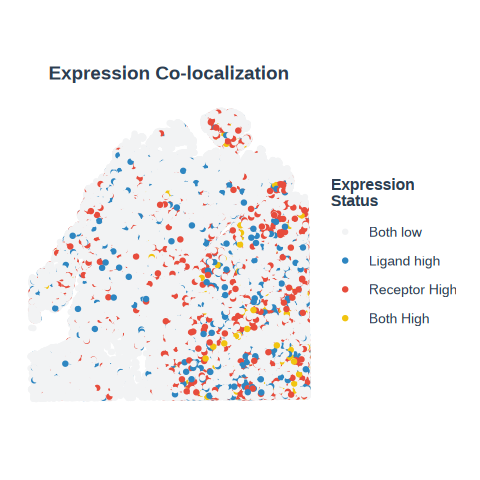

In [8]:
options(repr.plot.width = 4, repr.plot.height =4)  
plotLR2(CRC1_count,CRC1_loc,LRpair=c("MIF","CD44"))

In [9]:
sessionInfo()

R version 4.4.3 (2025-02-28)
Platform: x86_64-conda-linux-gnu
Running under: Ubuntu 16.04.6 LTS

Matrix products: default
BLAS/LAPACK: /home/amax/anaconda3/envs/cty3/lib/libopenblasp-r0.3.30.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=zh_CN.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=zh_CN.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=zh_CN.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=zh_CN.UTF-8 LC_IDENTIFICATION=C       

time zone: Asia/Shanghai
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] arrow_21.0.0       Seurat_5.3.0       SeuratObject_5.2.0 sp_2.2-0          
 [5] ggnewscale_0.5.2   lubridate_1.9.4    forcats_1.0.1      stringr_1.6.0     
 [9] purrr_1.1.0        readr_2.1.5        tidyr_1.3.1        tibble_3.3.0  